In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("data_load.py"))

from data_load import prepare_load_series, validate_load_series,load_electricity_370, normalize_by_max, scale_to_ieee_base
from data_solar import prepare_solar_series,load_solar_generation
# ── Config ──────────────────────────────────────────────────────
load_path   = "../datasets/LD2011_2014.txt"
solar_path  = "datasets/Plant_1_Generation_Data.csv"
OUTPUT_PATH = "datasets/processed/load_scaled.csv"
N_DAYS      = 60          # simulation horizon
IEEE_BASE   = 3.715       # MW — IEEE 33-bus rated capacity

print("Imports OK") 


Imports OK


---
## 2. Load Raw Data
Reads the full UCI dataset, aggregates 370 clients, converts kW → MW, and resamples 15-min → hourly.

In [2]:
# Paths to datasets
load_path = "datasets\LD2011_2014.txt"
solar_path = "datasets\Plant_1_Generation_Data.csv"   # change to your actual solar file name

# Generate processed series (60 days)
load = prepare_load_series(load_path, n_days=60)
solar = prepare_solar_series(solar_path, n_days=60)

# Align both series (VERY IMPORTANT)
min_len = min(len(load), len(solar))
load = load[:min_len]
solar = solar[:min_len]

# Output info
print("Load series created.")
print("Load Length:", len(load))

print("\nSolar series created.")
print("Solar Length:", len(solar))

# Optional: preview
print("\nFirst 5 Load values:")
print(load.head())

print("\nFirst 5 Solar values:")
print(solar.head())

<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:3: SyntaxWarning: invalid escape sequence '\P'
C:\Users\revan\AppData\Local\Temp\ipykernel_11456\1350999050.py:2: SyntaxWarning: invalid escape sequence '\L'
  load_path = "datasets\LD2011_2014.txt"
C:\Users\revan\AppData\Local\Temp\ipykernel_11456\1350999050.py:3: SyntaxWarning: invalid escape sequence '\P'
  solar_path = "datasets\Plant_1_Generation_Data.csv"   # change to your actual solar file name


Load series created.
Load Length: 796

Solar series created.
Solar Length: 796

First 5 Load values:
0    1.686109
1    1.620765
2    1.611883
3    1.626431
4    1.587026
dtype: float64

First 5 Solar values:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: AC_POWER, dtype: float64


In [3]:
# Align load and solar datasets to same time horizon

min_len = min(len(load), len(solar))

load = load.iloc[:min_len].reset_index(drop=True)
solar = solar.iloc[:min_len].reset_index(drop=True)

print(f"Aligned length: {min_len} hours")

Aligned length: 796 hours


In [4]:
# Load datasets
hourly_mw = load_electricity_370(load_path)
hourly_solar = load_solar_generation(solar_path)

# ── LOAD DATA SUMMARY ─────────────────────────────────────
print("\n===== LOAD DATA SUMMARY =====")
print(f"Shape       : {len(hourly_mw)} hours  ({len(hourly_mw)/24:.1f} days)")
print(f"Date range  : {hourly_mw.index.min()}  →  {hourly_mw.index.max()}")
print(f"Max load    : {hourly_mw.max():.4f} MW")
print(f"Min load    : {hourly_mw.min():.4f} MW")
print(f"Mean load   : {hourly_mw.mean():.4f} MW")
print(f"NaN count   : {hourly_mw.isna().sum()}")

# ── SOLAR DATA SUMMARY ────────────────────────────────────
print("\n===== SOLAR DATA SUMMARY =====")
print(f"Shape       : {len(hourly_solar)} hours  ({len(hourly_solar)/24:.1f} days)")
print(f"Date range  : {hourly_solar.index.min()}  →  {hourly_solar.index.max()}")
print(f"Max solar   : {hourly_solar.max():.4f} MW")
print(f"Min solar   : {hourly_solar.min():.4f} MW")
print(f"Mean solar  : {hourly_solar.mean():.4f} MW")
print(f"NaN count   : {hourly_solar.isna().sum()}")


===== LOAD DATA SUMMARY =====
Shape       : 35065 hours  (1461.0 days)
Date range  : 2011-01-01 00:00:00  →  2015-01-01 00:00:00
Max load    : 448.1488 MW
Min load    : 0.4545 MW
Mean load   : 195.5545 MW
NaN count   : 0

===== SOLAR DATA SUMMARY =====
Shape       : 796 hours  (33.2 days)
Date range  : 2020-05-15 00:00:00  →  2020-06-17 23:00:00
Max solar   : 27.3259 MW
Min solar   : 0.0000 MW
Mean solar  : 6.6958 MW
NaN count   : 0


### Raw Load — First 7 Days

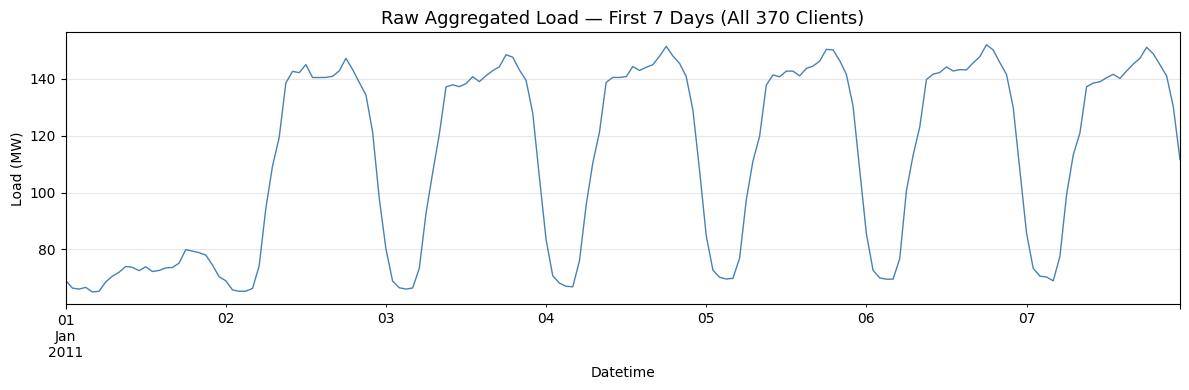

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
hourly_mw.iloc[:168].plot(ax=ax, color="steelblue", linewidth=1)
ax.set_title("Raw Aggregated Load — First 7 Days (All 370 Clients)", fontsize=13)
ax.set_xlabel("Datetime")
ax.set_ylabel("Load (MW)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Normalize → Scale → Trim

In [8]:
# Step 1: Max-normalize to [0, 1]
load_norm = normalize_by_max(hourly_mw)
print(f"After normalize  →  Max: {load_norm.max():.4f}  |  Min: {load_norm.min():.4f}")

# Step 2: Scale to IEEE 33-bus base load
load_scaled = scale_to_ieee_base(load_norm, base_mw=IEEE_BASE)
print(f"After scaling    →  Max: {load_scaled.max():.4f} MW  |  Min: {load_scaled.min():.4f} MW")

# Step 3: Trim to simulation horizon
load_scaled = load_scaled.iloc[: N_DAYS * 24].reset_index(drop=True)
print(f"After trim       →  {len(load_scaled)} hours  ({N_DAYS} days)")

After normalize  →  Max: 1.0000  |  Min: 0.0010
After scaling    →  Max: 3.7150 MW  |  Min: 0.0038 MW
After trim       →  1440 hours  (60 days)


---
## 4. Validate

In [10]:
assert load_scaled.isna().sum() == 0,          "FAIL: NaN values found"
assert load_scaled.min() >= 0.0,               "FAIL: Negative values found"
assert load_scaled.max() <= IEEE_BASE + 1e-6,  "FAIL: Load exceeds IEEE 33-bus capacity"

peak_idx  = load_scaled.idxmax()
peak_day  = peak_idx // 24
peak_hour = peak_idx % 24

print("All validation checks passed.")
print(f"\nFinal series summary:")
print(f"  Length     : {len(load_scaled)} hours")
print(f"  Min        : {load_scaled.min():.4f} MW")
print(f"  Max        : {load_scaled.max():.4f} MW  (Day {peak_day}, Hour {peak_hour}:00)")
print(f"  Mean       : {load_scaled.mean():.4f} MW")
print(f"  NaN count  : {load_scaled.isna().sum()}")

All validation checks passed.

Final series summary:
  Length     : 1440 hours
  Min        : 0.4814 MW
  Max        : 1.2606 MW  (Day 5, Hour 18:00)
  Mean       : 0.9520 MW
  NaN count  : 0


In [11]:
validate_load_series(load)

[VALID] Load series OK
        Length : 1440 hours
        Min    : 1.4186 MW
        Max    : 3.7150 MW
        Mean   : 2.8056 MW


---
## 5. Visualize Final Load Profile

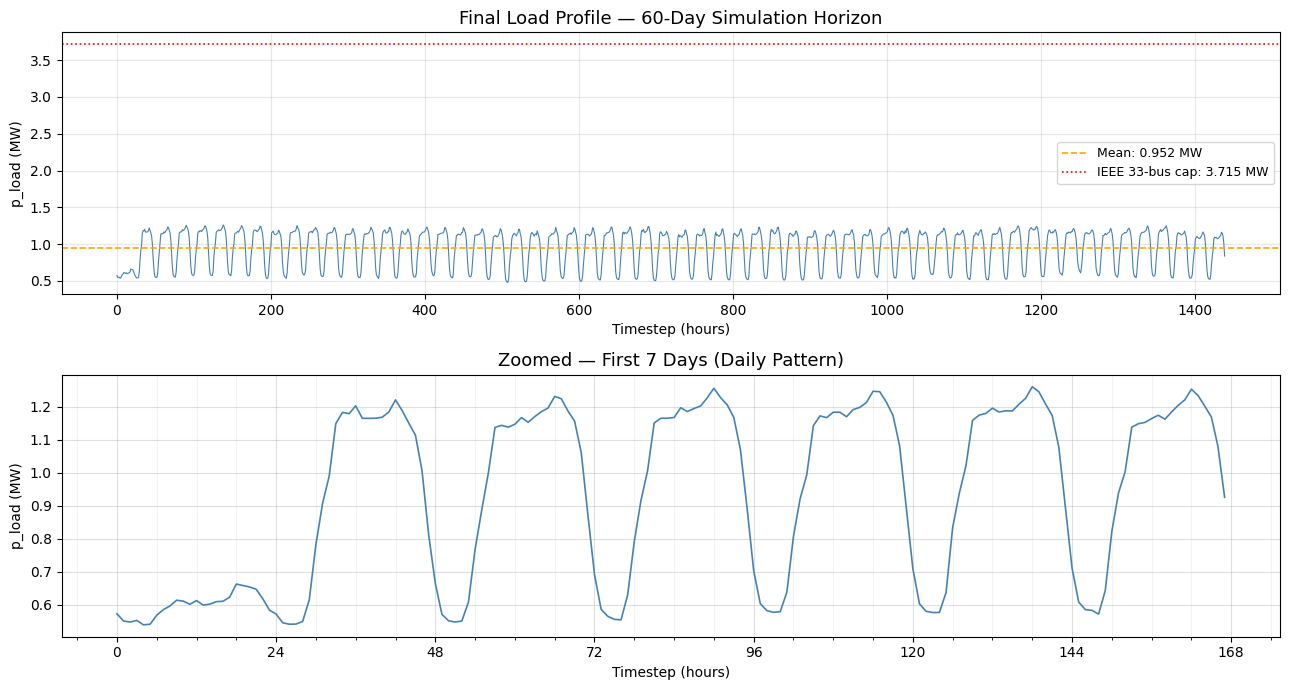

In [13]:
import matplotlib.ticker as ticker
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# ── Full simulation horizon ──────────────────────────────────────
axes[0].plot(load_scaled.values, color="steelblue", linewidth=0.8)
axes[0].axhline(load_scaled.mean(), color="orange", linestyle="--", linewidth=1.2, label=f"Mean: {load_scaled.mean():.3f} MW")
axes[0].axhline(IEEE_BASE, color="red", linestyle=":", linewidth=1.2, label=f"IEEE 33-bus cap: {IEEE_BASE} MW")
axes[0].set_title(f"Final Load Profile — {N_DAYS}-Day Simulation Horizon", fontsize=13)
axes[0].set_xlabel("Timestep (hours)")
axes[0].set_ylabel("p_load (MW)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── First 7 days zoomed ──────────────────────────────────────────
axes[1].plot(load_scaled.values[:168], color="steelblue", linewidth=1.2)
axes[1].set_title("Zoomed — First 7 Days (Daily Pattern)", fontsize=13)
axes[1].set_xlabel("Timestep (hours)")
axes[1].set_ylabel("p_load (MW)")
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(24))
axes[1].xaxis.set_minor_locator(ticker.MultipleLocator(6))
axes[1].grid(True, which="major", alpha=0.4)
axes[1].grid(True, which="minor", alpha=0.15)

plt.tight_layout()
plt.show()

In [14]:
prepare_load_series(path = "../datasets/electricityloaddiagrams20112014/LD2011_2014.txt", n_days=60)
peak_hour = load.idxmax()
print(f"Peak hour     : {peak_hour}")
print(f"Peak day      : {peak_hour // 24}")
print(f"Peak load     : {load.max():.4f} MW")
print(f"Peak load hour: {peak_hour % 24}:00")

Peak hour     : 138
Peak day      : 5
Peak load     : 3.7150 MW
Peak load hour: 18:00


In [15]:
print("\nBasic Statistics:")
print(load.describe())


Basic Statistics:
count    1440.000000
mean        2.805643
std         0.738126
min         1.418619
25%         2.010761
50%         3.252860
75%         3.403776
max         3.715000
dtype: float64


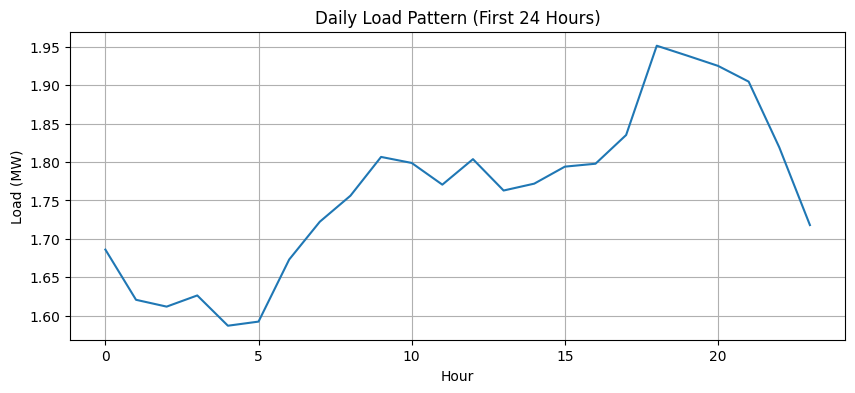

In [10]:
plt.figure(figsize=(10,4))
plt.plot(load[:24])
plt.title("Daily Load Pattern (First 24 Hours)")
plt.xlabel("Hour")
plt.ylabel("Load (MW)")
plt.grid()
plt.show()

---
## 6. Save

In [16]:
import os
import pandas as pd

output_path = "../datasets/processed/load_scaled.csv"

# ✅ Create folder if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

pd.DataFrame(load, columns=["load_mw"]).to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: ../datasets/processed/load_scaled.csv


In [17]:
check = pd.read_csv(output_path)

print("Reloaded file preview:")
print(check.head())

print("\nMax:", check["load_mw"].max())
print("Min:", check["load_mw"].min())
print("Length:", len(check))

Reloaded file preview:
    load_mw
0  1.686109
1  1.620765
2  1.611883
3  1.626431
4  1.587026

Max: 3.715
Min: 1.418619010630943
Length: 1440
